### Data description



Data comes from Jet Propulsion Laboratory Small-Body Database Query: https://ssd.jpl.nasa.gov/tools/sbdb_query.html

Dataset has 30 columns:
- diameter - diameter of the asteroid [target]
- full_name - Object full name
- a - semi-major axis
- e - eccentricity
- i - inclination with respect to x-y ecliptic plane(deg)
- om - longitude of the ascending node
- w - argument of perihelion
- q - perihelion distance(au)
- ad - aphelion distance(au)
- per_y - orbital periond(years)
- data_arc - data arc span(d)
- condition_code - orbit condition code
- n_obs_used - number of observation used
- H - absolute magnitude parameter
- neo - Near Earth Object
- pha - Physically Hazardous Asteroid
- extent - Object bi/tri axial ellipsoid dimensions(km)
- albedo - geometric albedo
- rot_per - rotation period(h)
- GM - standard gravitational parameter, Product of mass and gravitational constant
- BV - Color index B-V magnitude difference
- UB - Color index U-B magnitude difference
- IR - Color index I-R magnitude difference
- spec_B - Spectral taxonomic type(SMASSII)
- spec_T - Spectral taxonomic type(Tholen)
- G - magnitude slope parameter
- moid - Earth Minimum orbit Intersection Distance(au)
- class - asteroid orbit class
- n - mean motion(deg/d)
- ma - mean anomaly(deg)

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

In [150]:
FONT_SIZE = 13

COLOR_1 = '#748CAB'  # Midnight Blue
COLOR_2 = '#9DBEBB'  # Slate Gray
COLOR_3 = '#B5838D'  # Burgundy (for your third plot)
COLOR_GOLD = '#C5A059'

In [151]:
def null_percentage(df: pd.DataFrame, col_name: str) -> float:
    return round(df[col_name].isna().sum() / len(df) * 100, 2)

## Load the data

In [161]:
df = pd.read_csv('data/raw/asteroid_data.csv', low_memory=False)
df = df.copy()
df.T

,0,1,2,3,4,5,6,7,8,9,...,1471190,1471191,1471192,1471193,1471194,1471195,1471196,1471197,1471198,1471199
full_name,1 Ceres (A801 AA),2 Pallas (A802 FA),3 Juno (A804 RA),4 Vesta (A807 FA),5 Astraea (A845 XA),6 Hebe (A847 NA),7 Iris (A847 PA),8 Flora (A847 UA),9 Metis (A848 HA),10 Hygiea (A849 GA),...,(2025 UM6),(2025 UN6),(2025 UO6),(2025 UP6),(2025 UR6),(4847 P-L),(6331 P-L),(6344 P-L),(2015 BA620),(2015 BB620)
a,2.766,2.77,2.671,2.362,2.577,2.425,2.387,2.201,2.387,3.148,...,1.108,1.542,3.035,1.38,1.084,2.425,2.336,2.821,2.359,2.717
e,0.0796,0.2306,0.2558,0.0902,0.1875,0.2022,0.2302,0.1563,0.1226,0.1082,...,0.2196,0.4172,0.6044,0.3544,0.3062,0.2498,0.2827,0.6617,0.1297,0.1492
i,10.59,34.93,12.99,7.14,5.36,14.74,5.52,5.89,5.58,3.83,...,9.71,31.71,14.7,10.56,47.06,5.73,8.08,4.68,11.45,17.5
om,80.25,172.89,169.82,103.7,141.45,138.61,259.49,110.84,68.87,283.12,...,206.53,209.49,235.84,214.7,33.81,14.96,355.17,182.76,8.32,169.43
w,73.3,310.93,247.88,151.54,359.35,239.7,145.48,285.43,5.9,312.61,...,301.16,94.24,118.32,117.34,111.16,338.14,5.38,235.05,162.8,355.55
q,2.546,2.131,1.988,2.149,2.094,1.935,1.837,1.857,2.094,2.807,...,0.864,0.899,1.201,0.891,0.752,1.819,1.676,0.954,2.053,2.312
ad,2.99,3.41,3.35,2.57,3.06,2.92,2.94,2.55,2.68,3.49,...,1.35,2.19,4.87,1.87,1.42,3.03,3.0,4.69,2.67,3.12
per_y,4.6,4.61,4.37,3.63,4.14,3.78,3.69,3.27,3.69,5.58,...,1.17,1.91,5.29,1.62,1.13,3.78,3.57,4.74,3.62,4.48
data_arc,9520.0,80696.0,80649.0,25743.0,65619.0,64264.0,64432.0,64929.0,64291.0,64360.0,...,7.0,7.0,2.0,1.0,2.0,23388.0,23276.0,22229.0,3562.0,7.0


In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1471200 entries, 0 to 1471199
Data columns (total 30 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   full_name       1471200 non-null  object 
 1   a               1471200 non-null  float64
 2   e               1471200 non-null  float64
 3   i               1471200 non-null  float64
 4   om              1471200 non-null  float64
 5   w               1471200 non-null  float64
 6   q               1471200 non-null  float64
 7   ad              1471194 non-null  float64
 8   per_y           1471194 non-null  float64
 9   data_arc        1468709 non-null  float64
 10  condition_code  1471177 non-null  float64
 11  n_obs_used      1471200 non-null  int64  
 12  H               1470623 non-null  float64
 13  diameter        139591 non-null   float64
 14  extent          21 non-null       object 
 15  albedo          138468 non-null   float64
 16  rot_per         34595 non-null    fl

In [163]:
df.shape

(1471200, 30)

## Data analysis

#### Target: diameter

In [164]:
df.diameter.dtype

dtype('float64')

In [165]:
df = df.dropna(subset=['diameter'])

In [166]:
df.shape

(139591, 30)

In [167]:
df.diameter.describe()

count    139591.000000
mean          5.459478
std           9.307287
min           0.002500
25%           2.764000
50%           3.950000
75%           5.732000
max         939.400000
Name: diameter, dtype: float64

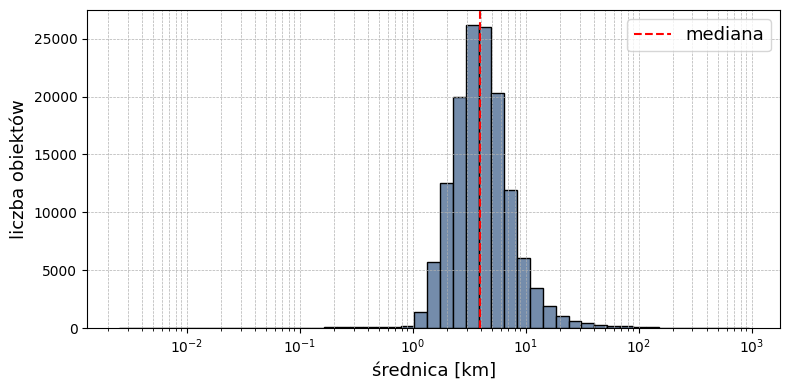

In [168]:
diameters = df['diameter'][df['diameter'] > 0]

bins = np.logspace(np.log10(diameters.min()), np.log10(diameters.max()), 50)

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(diameters, bins=bins, edgecolor='black', color=COLOR_1)

ax.set_xscale('log')

# ax.set_title("Histogram średnic")
ax.set_xlabel("średnica [km]", fontsize=FONT_SIZE)
ax.set_ylabel("liczba obiektów", fontsize=FONT_SIZE)
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

ax.axvline(diameters.median(), color='red', linestyle='--', label='mediana')
ax.legend(fontsize=FONT_SIZE)

plt.tight_layout()
plt.savefig('fig/analysis/diameter_histogram_log.pdf')

### Absolute Magnitude (H)

In [169]:
df_tmp = df.copy()

In [170]:
df_tmp.H.describe()

count    139149.000000
mean         15.342753
std           1.436207
min           3.250000
25%          14.590000
50%          15.430000
75%          16.230000
max          29.900000
Name: H, dtype: float64

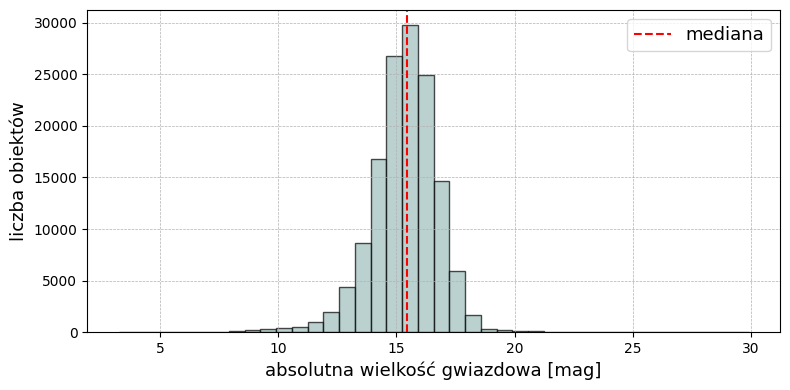

In [171]:
# Przygotowanie danych
magnitudes = df_tmp['H'].dropna()

# Rysowanie histogramu
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(magnitudes, bins=40, edgecolor='black', color=COLOR_2, alpha=0.7)
ax.set_xlabel('absolutna wielkość gwiazdowa [mag]', fontsize=FONT_SIZE)
ax.set_ylabel('liczba obiektów', fontsize=FONT_SIZE)
ax.grid(True, linestyle='--', linewidth=0.5)

# Dodanie linii mediany
ax.axvline(magnitudes.median(), color='red', linestyle='--', label='mediana')
ax.legend(fontsize=FONT_SIZE)

plt.tight_layout()
plt.savefig('fig/analysis/magnitude_histogram.pdf')

### Albedo

In [172]:
df_tmp['albedo'].describe()

count    138466.000000
mean          0.130113
std           0.110370
min           0.001000
25%           0.053000
50%           0.078000
75%           0.189000
max           1.000000
Name: albedo, dtype: float64

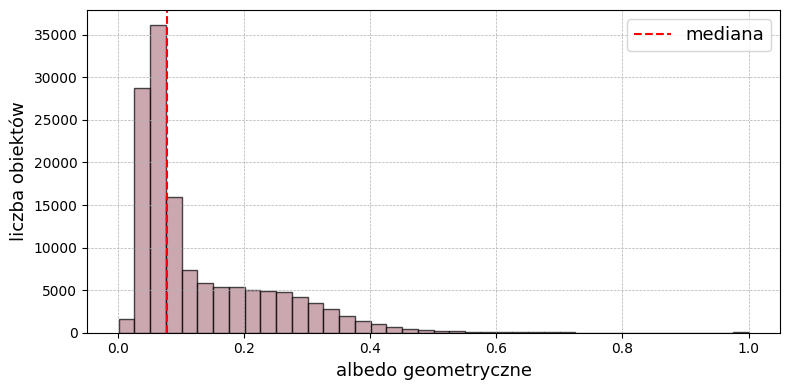

In [173]:
# Przygotowanie danych
albedo = df_tmp['albedo'].dropna()

# Rysowanie histogramu
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(albedo, bins=40, edgecolor='black', color=COLOR_3, alpha=0.7)
ax.set_xlabel('albedo geometryczne', fontsize=FONT_SIZE)
ax.set_ylabel('liczba obiektów', fontsize=FONT_SIZE)
ax.grid(True, linestyle='--', linewidth=0.5)

# Dodanie linii mediany
ax.axvline(albedo.median(), color='red', linestyle='--', label='mediana')
ax.legend(fontsize=FONT_SIZE)

plt.tight_layout()
plt.savefig('fig/analysis/albedo_histogram.pdf')

### Classes

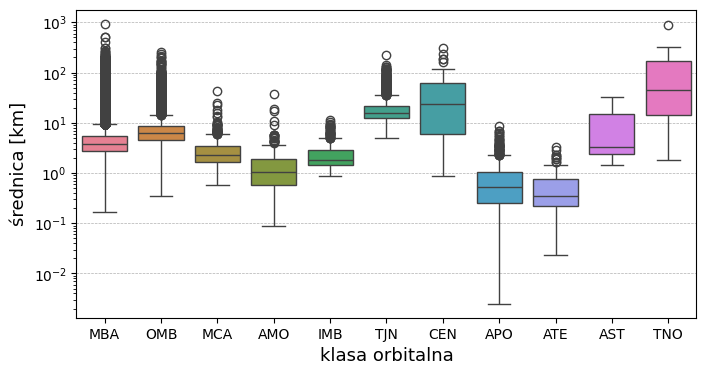

In [174]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_tmp, x='class', y='diameter', hue='class')
plt.yscale('log')  # optional if diameters are skewed
plt.xlabel('klasa orbitalna', fontsize=FONT_SIZE)
plt.ylabel('średnica [km]', fontsize=FONT_SIZE)
plt.grid(True, axis='y', linestyle='--', linewidth=0.5)
plt.savefig('fig/analysis/class_diameter_distribution.pdf')

Calculate mutual infor scores regression for dummies of each class with diameter variable

In [175]:
# One-hot encode
df_encoded = pd.get_dummies(df_tmp, columns=['class'], prefix='cls')

# Select dummy variables
X_dummies = df_encoded.filter(like='cls_')

# Compute mutual information
mi_scores = mutual_info_regression(X_dummies, df_encoded['diameter'])

# Create a DataFrame with class names and MI scores
mi_table = pd.DataFrame({
    'class': [col.replace('cls_', '') for col in X_dummies.columns],
    'mutual_info': mi_scores
}).sort_values(by='mutual_info', ascending=False)

In [176]:
mi_table.round(3)

,class,mutual_info
6,MBA,0.049
9,TJN,0.034
1,APO,0.023
8,OMB,0.023
0,AMO,0.007
7,MCA,0.005
5,IMB,0.005
4,CEN,0.004
3,ATE,0.003
2,AST,0.002


In [177]:
mi_table.round(3).to_csv('class_diameter_mi_scores.csv', index=False)

### Diameter, albedo and abolute magnitude relation

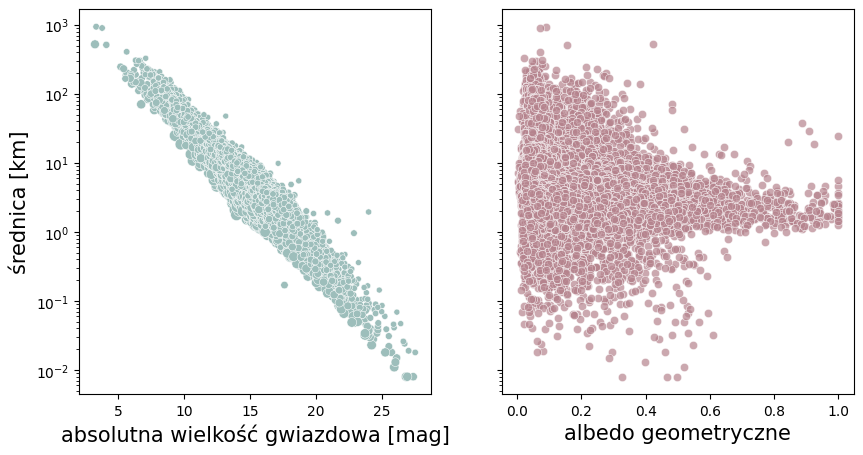

In [178]:
fig, ax = plt.subplots(1,2, figsize=(10,5), sharey=True)
# --- Left Plot ---
ax[0].set_yscale('log')
ax[0].set_ylabel('średnica [km]', fontsize=FONT_SIZE + 2)
ax[0].set_xlabel('absolutna wielkość gwiazdowa [mag]', fontsize=FONT_SIZE + 2)
ax[0].tick_params(axis='both') # Sizes of the numbers

sns.scatterplot(data=df_tmp, x='H', y='diameter', size='albedo', color=COLOR_2, ax=ax[0])
ax[0].legend().set_visible(False)

# --- Right Plot ---
ax[1].set_yscale('log')
ax[1].set_xlabel('albedo geometryczne', fontsize=FONT_SIZE+2)
ax[1].tick_params(axis='both')

sns.scatterplot(data=df_tmp, x='albedo', y='diameter', alpha=.7, color=COLOR_3, ax=ax[1])

plt.savefig('fig/analysis/diameter_albedo_magnitude_relation.png')

### Columns with too much missing data
Althought we see interesting columns describing spectral parameters (BV, UB, IR, spec_B, spec_T) as well as physical ones (extent, GM, G) and rotation period (rot_per), they have too much missing values to be of any use for model training. Because of that we drop them.

### Non-numeric columns

### Full name
We can safely assume that name of the asteroid doesn't impact it's diameter in any way, so we can drop that column.

In [179]:
df.full_name.isna().sum()

np.int64(0)

In [180]:
df.full_name.head()

0           1 Ceres (A801 AA)
1          2 Pallas (A802 FA)
2            3 Juno (A804 RA)
3           4 Vesta (A807 FA)
4         5 Astraea (A845 XA)
Name: full_name, dtype: object

### NEO and PHA
NEO (Near Earth Object) and PHA (Potentially Hazardous Asteroid) are boolean indicators whether the asteroids peryhelion is less than 1.3 AU (NEO) and whether its minimum orbit intersection distance with Earth is less than 0.05 AU and its absolute magnitude is 22 or brighter - it means that diameter is approximately larger than 140 meters (PHA).

In [181]:
null_percentage(df, 'neo'), null_percentage(df, 'pha')

(np.float64(0.0), np.float64(0.0))

Not many values are missing so we can fill them with majority in the future.

In [182]:
df_plot = df.copy()
df_plot['pha_plot'] = df['pha'].fillna('Missing')
df_plot['neo_plot'] = df['neo'].fillna('Missing')

### Feature importance

In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139591 entries, 0 to 1234644
Data columns (total 30 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   full_name       139591 non-null  object 
 1   a               139591 non-null  float64
 2   e               139591 non-null  float64
 3   i               139591 non-null  float64
 4   om              139591 non-null  float64
 5   w               139591 non-null  float64
 6   q               139591 non-null  float64
 7   ad              139591 non-null  float64
 8   per_y           139591 non-null  float64
 9   data_arc        139583 non-null  float64
 10  condition_code  139591 non-null  float64
 11  n_obs_used      139591 non-null  int64  
 12  H               139149 non-null  float64
 13  diameter        139591 non-null  float64
 14  extent          20 non-null      object 
 15  albedo          138466 non-null  float64
 16  rot_per         19929 non-null   float64
 17  GM            

In [184]:
tmp = df.copy()

In [185]:
too_much_na = []
for col in tmp.columns:

    null_pctg = null_percentage(tmp, col)

    if null_pctg > 50:
        too_much_na.append((col, null_pctg))

tmp = tmp.drop([c[0] for c in too_much_na], axis=1)

In [186]:
tmp.head()

,full_name,a,e,i,om,w,q,ad,per_y,data_arc,...,n_obs_used,H,diameter,albedo,ma,neo,pha,n,moid,class
0,1 Ceres (A801 AA),2.766,0.0796,10.59,80.25,73.30,2.546,2.99,4.60,9520.0,...,1075,3.34,939.400,0.0900,231.54,N,N,0.2143,1.58,MBA
1,2 Pallas (A802 FA),2.770,0.2306,34.93,172.89,310.93,2.131,3.41,4.61,80696.0,...,9750,4.11,513.000,0.1550,211.53,N,N,0.2138,1.23,MBA
2,3 Juno (A804 RA),2.671,0.2558,12.99,169.82,247.88,1.988,3.35,4.37,80649.0,...,8337,5.19,246.596,0.2140,217.59,N,N,0.2258,1.04,MBA
3,4 Vesta (A807 FA),2.362,0.0902,7.14,103.70,151.54,2.149,2.57,3.63,25743.0,...,9451,3.25,522.770,0.4228,26.81,N,N,0.2716,1.13,MBA
4,5 Astraea (A845 XA),2.577,0.1875,5.36,141.45,359.35,2.094,3.06,4.14,65619.0,...,4300,6.99,106.699,0.2740,133.87,N,N,0.2383,1.11,MBA


In [187]:
tmp = tmp.drop(['class', 'condition_code', 'pha', 'neo', 'full_name'], axis=1)
tmp.dropna()

X_tmp = tmp.drop(['diameter'], axis=1)
y_tmp = tmp['diameter']

In [188]:
tmp.head()

,a,e,i,om,w,q,ad,per_y,data_arc,n_obs_used,H,diameter,albedo,ma,n,moid
0,2.766,0.0796,10.59,80.25,73.30,2.546,2.99,4.60,9520.0,1075,3.34,939.400,0.0900,231.54,0.2143,1.58
1,2.770,0.2306,34.93,172.89,310.93,2.131,3.41,4.61,80696.0,9750,4.11,513.000,0.1550,211.53,0.2138,1.23
2,2.671,0.2558,12.99,169.82,247.88,1.988,3.35,4.37,80649.0,8337,5.19,246.596,0.2140,217.59,0.2258,1.04
3,2.362,0.0902,7.14,103.70,151.54,2.149,2.57,3.63,25743.0,9451,3.25,522.770,0.4228,26.81,0.2716,1.13
4,2.577,0.1875,5.36,141.45,359.35,2.094,3.06,4.14,65619.0,4300,6.99,106.699,0.2740,133.87,0.2383,1.11


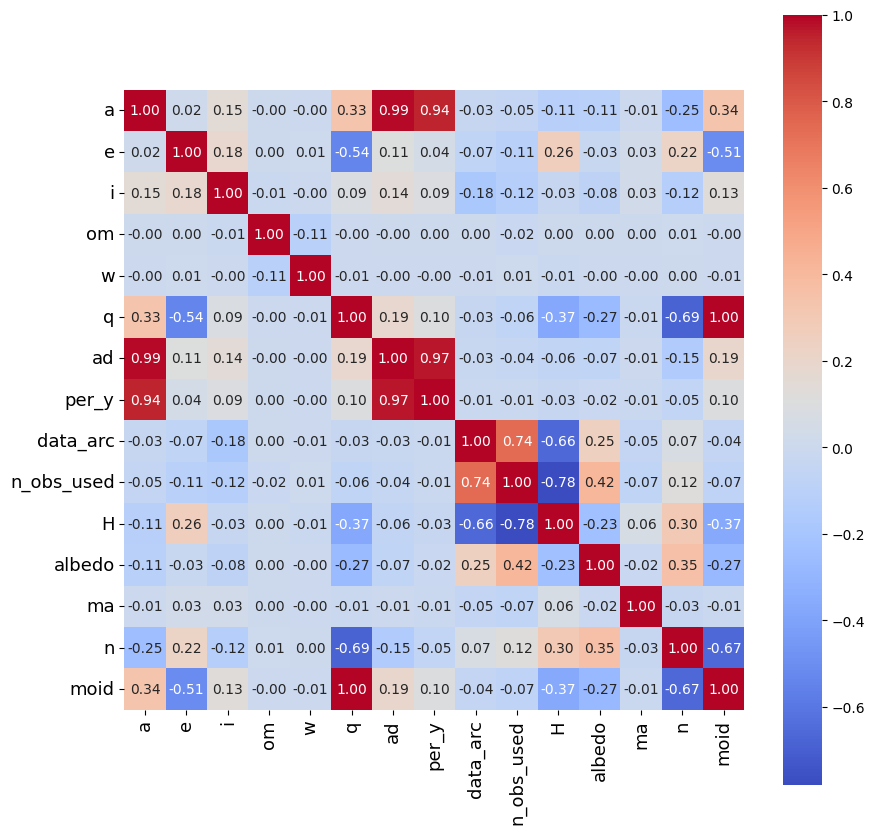

In [199]:
plt.figure(figsize=(10, 10))
ax = sns.heatmap(
    X_tmp.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True
)
ax.tick_params(axis='both', labelsize=FONT_SIZE)
plt.savefig('fig/analysis/correlation_matrix.pdf')

In [190]:
corr_y = X_tmp.corrwith(y_tmp)
corr_y = np.round(corr_y, 2)
corr_y.to_csv('correlation_with_target.csv')
corr_y

a             0.13
e            -0.06
i             0.05
om            0.00
w             0.00
q             0.33
ad            0.08
per_y         0.04
data_arc      0.50
n_obs_used    0.40
H            -0.56
albedo       -0.11
ma           -0.03
n            -0.19
moid          0.33
dtype: float64

In [191]:
mi = mutual_info_regression(X_tmp, y_tmp)

ValueError: Input X contains NaN.

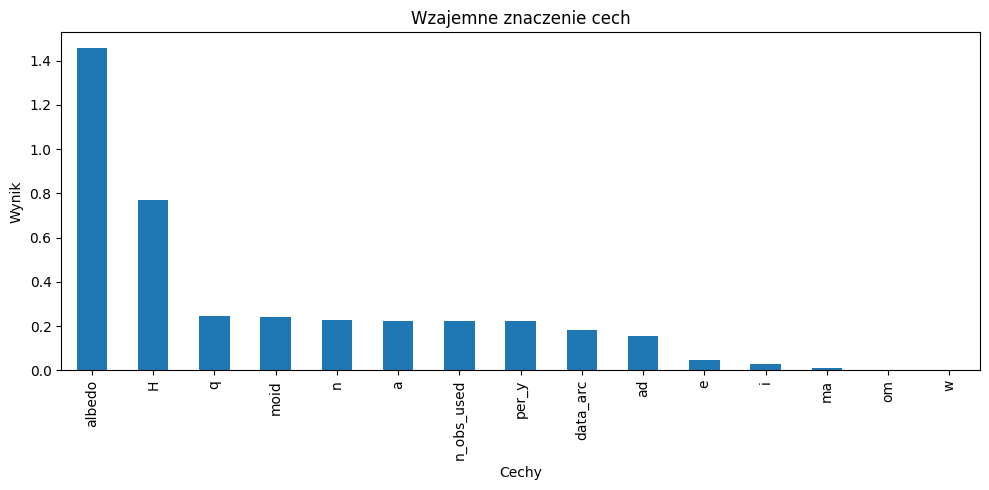

In [ ]:
mi_series = pd.Series(mi, index=X_tmp.columns)
mi_series = mi_series.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
mi_series.plot(kind='bar')
plt.title('Wzajemne znaczenie cech')
plt.ylabel('Wynik')
plt.xlabel('Cechy')
plt.tight_layout()
plt.savefig('fig/analysis/feature_importance.pdf')

## Data Engineering

In [155]:
df = df.copy()
df.shape

(1471200, 30)

In [ ]:
df = df.dropna(subset=['diameter'])

In [ ]:
too_much_na = []
for col in df.columns:

    null_pctg = null_percentage(df, col)

    if null_pctg > 50:
        too_much_na.append((col, null_pctg))

df = df.drop([c[0] for c in too_much_na], axis=1)

In [ ]:
n_largest_idx = df.nlargest(10, 'diameter').index
df = df.drop(n_largest_idx, axis=0)
df.nlargest(10, 'diameter')['diameter']

30       267.080
450      253.900
86       253.051
2        246.596
64       237.260
87       232.000
14       231.689
95625    230.500
623      225.000
15       222.000
Name: diameter, dtype: float64

#### Fill missing data

In [ ]:
df = df.dropna(subset=['data_arc', 'H', 'albedo'], axis=0)

In [ ]:
df.shape

(138020, 21)

#### X, y split

In [ ]:
X = df.drop(['diameter'], axis=1)
y = df['diameter']

In [ ]:
X.head()

,full_name,a,e,i,om,w,q,ad,per_y,data_arc,condition_code,n_obs_used,H,albedo,ma,neo,pha,n,moid,class
2,3 Juno (A804 RA),2.671,0.2558,12.99,169.82,247.88,1.988,3.35,4.37,80649.0,0.0,8337,5.19,0.2140,217.59,N,N,0.2258,1.040,MBA
4,5 Astraea (A845 XA),2.577,0.1875,5.36,141.45,359.35,2.094,3.06,4.14,65619.0,0.0,4300,6.99,0.2740,133.87,N,N,0.2383,1.110,MBA
5,6 Hebe (A847 NA),2.425,0.2022,14.74,138.61,239.70,1.935,2.92,3.78,64264.0,0.0,6734,5.61,0.2679,352.56,N,N,0.2609,0.976,MBA
6,7 Iris (A847 PA),2.387,0.2302,5.52,259.49,145.48,1.837,2.94,3.69,64432.0,0.0,5895,5.67,0.2766,61.73,N,N,0.2673,0.849,MBA
7,8 Flora (A847 UA),2.201,0.1563,5.89,110.84,285.43,1.857,2.55,3.27,64929.0,0.0,3564,6.61,0.2260,198.90,N,N,0.3018,0.874,MBA


In [ ]:
X = X.drop(['full_name'], axis=1)

Drop features with high correlation between them.

In [ ]:
X = X.drop(['q', 'ad'], axis=1)

Drop features without correlation to target and other features

In [ ]:
X = X.drop(['om', 'w'], axis=1)

Drop categorical features for now

In [ ]:
# X = pd.get_dummies(X, columns=['class'], dtype=int)
# X.shape
X = X.drop(['class'], axis=1)

Map flag categorical features to binary

In [ ]:
X['neo'] = X['neo'].map({'Y': 1, 'N': 0})
X['pha'] = X['pha'].map({'Y': 1, 'N': 0})


In [ ]:
X.shape

(138020, 14)

In [ ]:
X.head()

,a,e,i,per_y,data_arc,condition_code,n_obs_used,H,albedo,ma,neo,pha,n,moid
2,2.671,0.2558,12.99,4.37,80649.0,0.0,8337,5.19,0.2140,217.59,0,0,0.2258,1.040
4,2.577,0.1875,5.36,4.14,65619.0,0.0,4300,6.99,0.2740,133.87,0,0,0.2383,1.110
5,2.425,0.2022,14.74,3.78,64264.0,0.0,6734,5.61,0.2679,352.56,0,0,0.2609,0.976
6,2.387,0.2302,5.52,3.69,64432.0,0.0,5895,5.67,0.2766,61.73,0,0,0.2673,0.849
7,2.201,0.1563,5.89,3.27,64929.0,0.0,3564,6.61,0.2260,198.90,0,0,0.3018,0.874


In [ ]:
# X['albedo_sqrt'] = 1 / np.sqrt(X['albedo'])
# X['H_test'] = 10 ** (-1 * X['H'] / 5)

#### Add estimated diameter column
Column with diameter estimated based on H and albedo

In [ ]:
# def estimate_diameter(H, albedo):
#     p = 3.1236 - 0.5 * np.log10(albedo) - 0.2 * H
#     diameter = 10 ** p
#     return diameter

In [ ]:
# X_we = X.copy()
# X_we['estd'] = X_we.apply(lambda row: estimate_diameter(row['H'], row['albedo']), axis=1)
# X.shape, X_we.shape

In [ ]:
# X_we['estd'].corr(y)

## Train the models

Using the modular ML framework for easy model comparison and hyperparameter tuning.

In [ ]:
# Import the modular framework
import sys
sys.path.append('src')

from training import ModelTrainer
from evaluation import ModelEvaluator, ModelComparison
from tuning import HyperparameterTuner
from models import (
    LinearRegressionModel, ElasticNetModel, KNeighborsRegressorModel,
    RandomForestRegressorModel, GradientBoostingRegressorModel,
    XGBRegressorModel, LGBMRegressorModel, SVRModel,
    MLPRegressorModel, ClassicalDiameterModel
)

# Initialize trainer (handles data splitting and preprocessing)
trainer = ModelTrainer(test_size=0.15, val_size=0.15, random_state=3, 
                       scale_features=True, use_log_transform=False)
trainer.prepare_data(X, y)

# trainer_we = ModelTrainer(test_size=0.15, val_size=0.15, random_state=3, 
#                        scale_features=True, use_log_transform=False)
# trainer_we.prepare_data(X_we, y)

# Get data splits
X_train, y_train = trainer.get_train_data(scaled=True)
X_val, y_val = trainer.get_val_data(scaled=True)
X_test, y_test = trainer.get_test_data(scaled=True)


# Get unscaled data
X_train_unscaled, y_train_unscaled = trainer.get_train_data(scaled=False)
X_val_unscaled, y_val_unscaled = trainer.get_val_data(scaled=False)
X_test_unscaled, y_test_unscaled = trainer.get_test_data(scaled=False)

# X_train_unscaled_we, y_train_unscaled_we = trainer_we.get_train_data(scaled=False)
# X_val_unscaled_we, y_val_unscaled_we = trainer_we.get_val_data(scaled=False)
# X_test_unscaled_we, y_test_unscaled_we = trainer_we.get_test_data(scaled=False)

print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Val set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (99719, 14), (99719,)
Val set: (17598, 14), (17598,)
Test set: (20703, 14), (20703,)


In [ ]:
# Initialize evaluator and comparison utilities
evaluator = ModelEvaluator(fig_dir='fig')
comparison = ModelComparison(fig_dir='fig')

# Initialize hyperparameter tuner
tuner = HyperparameterTuner(config_path='src/config/model_configs.yaml')

In [ ]:
# Dictionary to store trained models
trained_models = {}
tuned_models = {}

### Classical diameter approximation

In [ ]:
# Classical model doesn't need scaling - use original DataFrame
X_test_df, _ = trainer.get_test_data(scaled=False)
classical_model = ClassicalDiameterModel()
classical_model.fit(X_test_df, y_test_unscaled)
classical_preds = classical_model.predict(X_test_df)

# Evaluate
classical_metrics = evaluator.evaluate(y_test_unscaled, classical_preds, 'Classical')
evaluator.plot_predictions(y_test_unscaled, classical_preds, 'Classical')
comparison.add_result('Classical', classical_metrics)
trained_models['Classical'] = classical_model

print(f"Classical Model - RMSE: {classical_metrics['rmse']:.3f}, MSE: {classical_metrics['mse']:.3f}, MAE: {classical_metrics['mae']:.3f}, R²: {classical_metrics['r2']:.3f}")

Classical Model - RMSE: 1.301, MSE: 1.692, MAE: 0.685, R²: 0.969


### Linear Regression

In [ ]:
lr_model = LinearRegressionModel()
trainer.train_model(lr_model, use_val_for_training=False)
lr_preds = lr_model.predict(X_test)

lr_metrics = evaluator.evaluate(y_test, lr_preds, 'Linear Regression')
evaluator.plot_predictions(y_test, lr_preds, 'Linear Regression')
evaluator.plot_residuals(y_test, lr_preds, 'Linear Regression')
comparison.add_result('Linear Regression', lr_metrics)
trained_models['Linear Regression'] = lr_model

print(f"Linear Regression - RMSE: {lr_metrics['rmse']:.3f}, MSE: {lr_metrics['mse']:.3f}, MAE: {lr_metrics['mae']:.3f}, R²: {lr_metrics['r2']:.3f}")

Linear Regression - RMSE: 4.944, MSE: 24.442, MAE: 2.322, R²: 0.556


### Elastic Net

In [ ]:
elastic_model = ElasticNetModel(alpha=0.001, l1_ratio=0.9)
trainer.train_model(elastic_model)
elastic_preds = elastic_model.predict(X_test)

elastic_metrics = evaluator.evaluate(y_test_unscaled, elastic_preds, 'Elastic Net')
evaluator.plot_predictions(y_test, elastic_preds, 'Elastic Net')
comparison.add_result('Elastic Net', elastic_metrics)
trained_models['Elastic Net'] = elastic_model

print(f"Elastic Net - RMSE: {elastic_metrics['rmse']:.3f}, MSE: {elastic_metrics['mse']:.3f}, MAE: {elastic_metrics['mae']:.3f}, R²: {elastic_metrics['r2']:.3f}")

Elastic Net - RMSE: 4.942, MSE: 24.421, MAE: 2.318, R²: 0.556


In [ ]:
print("=== Tuning Elastic Net ===")
elastic_model_tuned = ElasticNetModel()
elastic_model_tuned, elastic_study = tuner.tune_model(
    elastic_model_tuned, X_train, y_train, 'elastic_net',
    n_iter=20, cv=5, n_jobs=8, verbose=1
)

print(f"\nBest parameters: {elastic_study.best_params}")
print(f"Best CV score: {elastic_study.best_value:.4f}")

# Evaluate tuned model
elastic_tuned_preds = elastic_model_tuned.predict(X_test)
elastic_tuned_metrics = evaluator.evaluate(y_test, elastic_tuned_preds, 'Elastic Net (Tuned)')
evaluator.plot_predictions(y_test, elastic_tuned_preds, 'Elastic Net (Tuned)')
comparison.add_result('Elastic Net (Tuned)', elastic_tuned_metrics)
tuned_models['Elastic Net'] = elastic_model_tuned

print(f"Elastic Net (Tuned) - MSE: {elastic_tuned_metrics['mse']:.3f}, R²: {elastic_tuned_metrics['r2']:.3f}")


[I 2026-01-25 21:08:22,925] A new study created in memory with name: no-name-a3a5f63e-938b-459c-8fd3-fadf2b46f3d0


=== Tuning Elastic Net ===


  0%|          | 0/20 [00:04<?, ?it/s]

[W 2026-01-25 21:08:27,551] Trial 0 failed with parameters: {'alpha': 0.37460266483547777, 'l1_ratio': 0.9507143064099162} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/home/stpaulo/asteroid-diameter-prediction/src/tuning/hyperparameter_tuning.py", line 150, in objective
    scores = cross_val_score(sklearn_model, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packag

KeyboardInterrupt: 

### K-Nearest Neighbors

In [ ]:
knn_model = KNeighborsRegressorModel(
    # n_neighbors=8,
    # weights='distance',
    # p=1
)
trainer.train_model(knn_model, use_val_for_training=True)
knn_preds = knn_model.predict(X_test)

knn_metrics = evaluator.evaluate(y_test_unscaled, knn_preds, 'KNN')
evaluator.plot_predictions(y_test_unscaled, knn_preds, 'KNN')
comparison.add_result('KNN', knn_metrics)
trained_models['KNN'] = knn_model

print(f"KNN - RMSE: {knn_metrics['rmse']:.3f}, MSE: {knn_metrics['mse']:.3f}, MAE: {knn_metrics['mae']:.3f}, R²: {knn_metrics['r2']:.3f}")

KNN - RMSE: 2.283, MSE: 5.212, MAE: 0.645, R²: 0.913


In [ ]:
print("=== Tuning KNN ===")
knn_model_tuned = KNeighborsRegressorModel()
knn_model_tuned, knn_study = tuner.tune_model(
    knn_model_tuned, X_train, y_train, 'knn',
    n_iter=10, cv=5, n_jobs=8, verbose=1
)

print(f"\nBest parameters: {knn_study.best_params}")
print(f"Best CV score: {knn_study.best_value:.4f}")

# Evaluate tuned model
knn_tuned_preds = knn_model_tuned.predict(X_test)
knn_tuned_metrics = evaluator.evaluate(y_test, knn_tuned_preds, 'KNN (Tuned)')
evaluator.plot_predictions(y_test, knn_tuned_preds, 'KNN (Tuned)')
comparison.add_result('KNN (Tuned)', knn_tuned_metrics)
tuned_models['KNN'] = knn_model_tuned

print(f"KNN (Tuned) - RMSE: {knn_tuned_metrics['rmse']:.3f}, R²: {knn_tuned_metrics['r2']:.3f}")

[I 2026-01-25 19:38:11,941] A new study created in memory with name: no-name-c20499a5-a53b-41f2-b53a-a6032222492b


=== Tuning KNN ===


  0%|          | 0/10 [00:24<?, ?it/s]

[W 2026-01-25 19:38:36,828] Trial 0 failed with parameters: {'n_neighbors': 19, 'weights': 'uniform', 'p': 1} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/home/stpaulo/asteroid-diameter-prediction/src/tuning/hyperparameter_tuning.py", line 150, in objective
    scores = cross_val_score(sklearn_model, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/sklearn/mo

KeyboardInterrupt: 

### Random Forest

In [ ]:
rf_model = RandomForestRegressorModel()
trainer.train_model(rf_model)
rf_preds = rf_model.predict(X_test)

rf_metrics = evaluator.evaluate(y_test_unscaled, rf_preds, 'Random Forest')
evaluator.plot_predictions(y_test_unscaled, rf_preds, 'Random Forest')
evaluator.plot_residuals(y_test_unscaled, rf_preds, 'Random Forest')
comparison.add_result('Random Forest', rf_metrics)
trained_models['Random Forest'] = rf_model

print(f"Random Forest - RMSE: {rf_metrics['rmse']:.3f}, MSE: {rf_metrics['mse']:.3f}, MAE: {rf_metrics['mae']:.3f}, R²: {rf_metrics['r2']:.3f}")

Random Forest - RMSE: 0.998, MSE: 0.995, MAE: 0.397, R²: 0.983


In [ ]:
print("=== Tuning Random Forest ===")
rf_model_tuned = RandomForestRegressorModel()
rf_model_tuned, rf_study = tuner.tune_model(
    rf_model_tuned, X_train, y_train, 'random_forest',
    n_iter=10, cv=5, n_jobs=-1, verbose=1
)

print(f"\nBest parameters: {rf_study.best_params}")
print(f"Best CV score: {rf_study.best_value:.4f}")

# Evaluate tuned model
rf_tuned_preds = rf_model_tuned.predict(X_test)
rf_tuned_metrics = evaluator.evaluate(y_test, rf_tuned_preds, 'Random Forest (Tuned)')
evaluator.plot_predictions(y_test, rf_tuned_preds, 'Random Forest (Tuned)')
comparison.add_result('Random Forest (Tuned)', rf_tuned_metrics)
tuned_models['Random Forest'] = rf_model_tuned

print(f"Random Forest (Tuned) - RMSE: {rf_tuned_metrics['rmse']:.3f}, R²: {rf_tuned_metrics['r2']:.3f}")


[I 2026-01-25 19:25:30,488] A new study created in memory with name: no-name-32cb0120-447d-4473-8866-762405279d5e


=== Tuning Random Forest ===


Best trial: 0. Best value: -1.22018:  10%|█         | 1/10 [01:42<15:18, 102.03s/it]

[I 2026-01-25 19:27:12,515] Trial 0 finished with value: -1.2201809159544752 and parameters: {'n_estimators': 144, 'max_depth': 48, 'min_samples_split': 15, 'min_samples_leaf': 6}. Best is trial 0 with value: -1.2201809159544752.


Best trial: 0. Best value: -1.22018:  20%|██        | 2/10 [02:30<09:21, 70.24s/it] 

...

Best trial: 0. Best value: -1.22018:  30%|███       | 3/10 [04:55<12:11, 104.46s/it]

[I 2026-01-25 19:30:25,689] Trial 2 finished with value: -1.3740433015171605 and parameters: {'n_estimators': 200, 'max_depth': 37, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 0 with value: -1.2201809159544752.


Best trial: 0. Best value: -1.22018:  30%|███       | 3/10 [06:44<15:44, 134.94s/it]

[W 2026-01-25 19:32:15,311] Trial 3 failed with parameters: {'n_estimators': 258, 'max_depth': 14, 'min_samples_split': 5, 'min_samples_leaf': 2} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/home/stpaulo/asteroid-diameter-prediction/src/tuning/hyperparameter_tuning.py", line 150, in objective
    scores = cross_val_score(sklearn_model, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/stpaulo/asteroid-diameter-prediction/.venv/lib

KeyboardInterrupt: 

### Gradient Boosting

In [ ]:
gb_model = GradientBoostingRegressorModel()
trainer.train_model(gb_model)
gb_preds = gb_model.predict(X_test)

gb_metrics = evaluator.evaluate(y_test, gb_preds, 'Gradient Boosting')
evaluator.plot_predictions(y_test, gb_preds, 'Gradient Boosting')
comparison.add_result('Gradient Boosting', gb_metrics)
trained_models['Gradient Boosting'] = gb_model

print(f"Gradient Boosting - RMSE: {gb_metrics['rmse']:.3f}, MSE: {gb_metrics['mse']:.3f}, MAE: {gb_metrics['mae']:.3f}, R²: {gb_metrics['r2']:.3f}")

Gradient Boosting - RMSE: 1.022, MSE: 1.044, MAE: 0.459, R²: 0.983


In [ ]:
print("=== Tuning Gradient Boosting ===")
gb_model_tuned = GradientBoostingRegressorModel()
gb_model_tuned, gb_study = tuner.tune_model(
    gb_model_tuned, X_train, y_train, 'gradient_boosting',
    n_iter=10, cv=5, n_jobs=4, verbose=1
)

print(f"\nBest parameters: {gb_study.best_params}")
print(f"Best CV score: {gb_study.best_value:.4f}")

# Evaluate tuned model
gb_tuned_preds = gb_model_tuned.predict(X_test)
gb_tuned_metrics = evaluator.evaluate(y_test, gb_tuned_preds, 'Gradient Boosting (Tuned)')
evaluator.plot_predictions(y_test, gb_tuned_preds, 'Gradient Boosting (Tuned)')
comparison.add_result('Gradient Boosting (Tuned)', gb_tuned_metrics)
tuned_models['Gradient Boosting'] = gb_model_tuned

print(f"Gradient Boosting (Tuned) - RMSE: {gb_tuned_metrics['rmse']:.3f}, R²: {gb_tuned_metrics['r2']:.3f}")

[I 2026-01-18 04:08:12,107] A new study created in memory with name: no-name-d381b1bc-2c09-4855-a1dc-1a3a2b655343


=== Tuning Gradient Boosting ===


  0%|          | 0/50 [03:33<?, ?it/s]

[W 2026-01-18 04:11:45,703] Trial 0 failed with parameters: {'n_estimators': 144, 'learning_rate': 0.28570714885887566, 'max_depth': 8, 'min_samples_split': 13} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/home/stpaulo/asteroid-diameter-prediction/src/tuning/hyperparameter_tuning.py", line 150, in objective
    scores = cross_val_score(sklearn_model, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/stpaulo/asteroid-diameter-predi

KeyboardInterrupt: 

### XGBoost


In [ ]:

xgb_model = XGBRegressorModel(
    booster='gbtree',
    device='cuda',
    verbosity=0,
    learning_rate=0.2,
    min_split_loss=20,
    min_child_weight=1,
    subsample=0.6,
    sampling_method='gradient_based',
    
)
trainer.train_model(xgb_model)
xgb_preds = xgb_model.predict(X_test)

xgb_metrics = evaluator.evaluate(y_test_unscaled, xgb_preds, 'XGBoost')
evaluator.plot_predictions(y_test_unscaled, xgb_preds, 'XGBoost')
comparison.add_result('XGBoost', xgb_metrics)
trained_models['XGBoost'] = xgb_model

print(f"XGBoost - RMSE: {xgb_metrics['rmse']:.3f}, MSE: {xgb_metrics['mse']:.3f}, MAE: {xgb_metrics['mae']:.3f}, R²: {xgb_metrics['r2']:.3f}")

XGBoost - RMSE: 2.351, MSE: 5.529, MAE: 0.513, R²: 0.908


In [ ]:
print("=== Tuning XGBoost ===")
xgb_model_tuned = XGBRegressorModel()
xgb_model_tuned, xgb_study = tuner.tune_model(
    xgb_model_tuned, X_train, y_train, 'xgboost',
    n_iter=10, cv=5, n_jobs=3, verbose=1
)

print(f"\nBest parameters: {xgb_study.best_params}")
print(f"Best CV score: {xgb_study.best_value:.4f}")

# Evaluate tuned model
xgb_tuned_preds = xgb_model_tuned.predict(X_test)
xgb_tuned_metrics = evaluator.evaluate(y_test, xgb_tuned_preds, 'XGBoost (Tuned)')
evaluator.plot_predictions(y_test, xgb_tuned_preds, 'XGBoost (Tuned)')
comparison.add_result('XGBoost (Tuned)', xgb_tuned_metrics)
tuned_models['XGBoost'] = xgb_model_tuned

print(f"XGBoost (Tuned) - RMSE: {xgb_tuned_metrics['rmse']:.3f}, R²: {xgb_tuned_metrics['r2']:.3f}")

[I 2026-01-25 20:27:53,140] A new study created in memory with name: no-name-a5339106-4dc0-4e7c-8981-d44de7b90955


=== Tuning XGBoost ===


Best trial: 0. Best value: -8.16606:  10%|█         | 1/10 [00:06<00:57,  6.35s/it]

[I 2026-01-25 20:27:59,494] Trial 0 finished with value: -8.166062490823075 and parameters: {'learning_rate': 0.3807947176588889, 'max_depth': 20, 'min_child_weight': 8, 'max_delta_step': 6, 'subsample': 0.24041677639819287, 'sampling_method': 'uniform'}. Best is trial 0 with value: -8.166062490823075.


Best trial: 0. Best value: -8.16606:  20%|██        | 2/10 [00:07<00:24,  3.06s/it]

...

[I 2026-01-25 20:28:26,175] Trial 7 finished with value: -10.044640964458086 and parameters: {'learning_rate': 0.8103133746352965, 'max_depth': 10, 'min_child_weight': 1, 'max_delta_step': 7, 'subsample': 0.4961372443656412, 'sampling_method': 'uniform'}. Best is trial 0 with value: -8.166062490823075.


Best trial: 8. Best value: -7.77536:  90%|█████████ | 9/10 [00:40<00:04,  4.66s/it]

[I 2026-01-25 20:28:34,039] Trial 8 finished with value: -7.77535888197193 and parameters: {'learning_rate': 0.13081785249633104, 'max_depth': 13, 'min_child_weight': 1, 'max_delta_step': 10, 'subsample': 0.3329019834400152, 'sampling_method': 'uniform'}. Best is trial 8 with value: -7.77535888197193.


Best trial: 8. Best value: -7.77536: 100%|██████████| 10/10 [00:42<00:00,  4.23s/it]


[I 2026-01-25 20:28:35,437] Trial 9 finished with value: -11.425799964653397 and parameters: {'learning_rate': 0.6658970615104421, 'max_depth': 10, 'min_child_weight': 6, 'max_delta_step': 6, 'subsample': 0.26636900997297436, 'sampling_method': 'uniform'}. Best is trial 8 with value: -7.77535888197193.

Best parameters: {'learning_rate': 0.13081785249633104, 'max_depth': 13, 'min_child_weight': 1, 'max_delta_step': 10, 'subsample': 0.3329019834400152, 'sampling_method': 'uniform'}
Best CV score: -7.7754
XGBoost (Tuned) - RMSE: 2.656, R²: 0.882


### LightGBM

In [ ]:
lgbm_model = LGBMRegressorModel(
    verbosity=0
)
trainer.train_model(lgbm_model)
lgbm_preds = lgbm_model.predict(X_test)

lgbm_metrics = evaluator.evaluate(y_test_unscaled, lgbm_preds, 'LightGBM')
evaluator.plot_predictions(y_test_unscaled, lgbm_preds, 'LightGBM')
comparison.add_result('LightGBM', lgbm_metrics)
trained_models['LightGBM'] = lgbm_model

print(f"LightGBM - RMSE: {lgbm_metrics['rmse']:.3f}, MSE: {lgbm_metrics['mse']:.3f}, MAE: {lgbm_metrics['mae']:.3f}, R²: {lgbm_metrics['r2']:.3f}")

/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM - RMSE: 2.396, MSE: 5.742, MAE: 0.526, R²: 0.904


In [ ]:
print("=== Tuning LightGBM ===")
lgbm_model_tuned = LGBMRegressorModel()
lgbm_model_tuned, lgbm_study = tuner.tune_model(
    lgbm_model_tuned, X_train, y_train, 'lightgbm',
    n_iter=10, cv=5, n_jobs=3, verbose=1
)

print(f"\nBest parameters: {lgbm_study.best_params}")
print(f"Best CV score: {lgbm_study.best_value:.4f}")

# Evaluate tuned model
lgbm_tuned_preds = lgbm_model_tuned.predict(X_test)
lgbm_tuned_metrics = evaluator.evaluate(y_test, lgbm_tuned_preds, 'LightGBM (Tuned)')
evaluator.plot_predictions(y_test, lgbm_tuned_preds, 'LightGBM (Tuned)')
comparison.add_result('LightGBM (Tuned)', lgbm_tuned_metrics)
tuned_models['LightGBM'] = lgbm_model_tuned

print(f"LightGBM (Tuned) - RMSE: {lgbm_tuned_metrics['rmse']:.3f}, R²: {lgbm_tuned_metrics['r2']:.3f}")


[I 2026-01-25 20:43:47,761] A new study created in memory with name: no-name-740f010c-cd6b-49cc-a284-50d43d3e09d4


=== Tuning LightGBM ===


  0%|          | 0/10 [00:00<?, ?it/s]

[LightGBM] [Warning] min_data_in_leaf is set=96, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=96
[LightGBM] [Warning] bagging_fraction is set=0.1628982676335878, subsample=1.0 will be ignored. Current value: bagging_fraction=0.1628982676335878
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] min_data_in_leaf is set=96, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=96
[LightGBM] [Warning] bagging_fraction is set=0.1628982676335878, subsample=1.0 will be ignored. Current value: bagging_fraction=0.1628982676335878
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001806 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2822
[LightGBM] [Info] Number of data points in the tra

/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

[LightGBM] [Warning] min_data_in_leaf is set=38, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=38
[LightGBM] [Warning] bagging_fraction is set=0.19115736641501652, subsample=1.0 will be ignored. Current value: bagging_fraction=0.19115736641501652
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.114517 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2822
[LightGBM] [Info] Number of data points in the train set: 80677, number of used features: 14
[LightGBM] [Info] Start training from score 5.428862
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Best trial: 6. Best value: -6.88835: 100%|██████████| 10/10 [02:35<00:00, 15.54s/it]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f


/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Best parameters: {'num_leaves': 190, 'min_data_in_leaf': 25, 'max_depth': 4, 'bagging_freq': 10, 'bagging_fraction': 0.9563193924130682}
Best CV score: -6.8883
LightGBM (Tuned) - RMSE: 2.396, R²: 0.904


### Support Vector Regression

In [ ]:
svr_model = SVRModel()
trainer.train_model(svr_model)
svr_preds = svr_model.predict(X_test)

svr_metrics = evaluator.evaluate(y_test_unscaled, svr_preds, 'SVR')
evaluator.plot_predictions(y_test_unscaled, svr_preds, 'SVR')
comparison.add_result('SVR', svr_metrics)
trained_models['SVR'] = svr_model

print(f"SVR - RMSE: {svr_metrics['rmse']:.3f}, MSE: {svr_metrics['mse']:.3f}, MAE: {svr_metrics['mae']:.3f}, R²: {svr_metrics['r2']:.3f}")

SVR - RMSE: 3.643, MSE: 13.275, MAE: 0.543, R²: 0.759


In [ ]:
print("=== Tuning SVR ===")
svr_model_tuned = SVRModel()
svr_model_tuned, svr_study = tuner.tune_model(
    svr_model_tuned, X_train, y_train, 'svr',
    n_iter=30, cv=3, n_jobs=3, verbose=1
) 
svr_tuned_preds = svr_model_tuned.predict(X_test)
svr_tuned_metrics = evaluator.evaluate(y_test, svr_tuned_preds, 'SVR (Tuned)')
evaluator.plot_predictions(y_test, svr_tuned_preds, 'SVR (Tuned)')
comparison.add_result('SVR (Tuned)', svr_tuned_metrics)
tuned_models['SVR'] = svr_model_tuned

print(f"SVR (Tuned) - RMSE: {svr_tuned_metrics['rmse']:.3f}, R²: {svr_tuned_metrics['r2']:.3f}")


[I 2026-01-19 20:37:36,547] A new study created in memory with name: no-name-5f5c4b62-618e-440b-b562-105425f676ba


=== Tuning SVR ===


Best trial: 0. Best value: -8.04616:   3%|▎         | 1/30 [04:15<2:03:20, 255.19s/it]

[I 2026-01-19 20:41:51,739] Trial 0 finished with value: -8.04616489113305 and parameters: {'C': 37.516557872851514, 'epsilon': 0.951207163345817, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: -8.04616489113305.


Best trial: 0. Best value: -8.04616:   3%|▎         | 1/30 [1:34:39<45:45:13, 5679.78s/it]


[W 2026-01-19 22:12:16,319] Trial 1 failed with parameters: {'C': 86.63099696291603, 'epsilon': 0.6051038616257767, 'kernel': 'poly', 'gamma': 'scale'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/home/stpaulo/asteroid-diameter-prediction/src/tuning/hyperparameter_tuning.py", line 150, in objective
    scores = cross_val_score(sklearn_model, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/stpaulo/asteroid-diameter-prediction/.ve

KeyboardInterrupt: 

### Multi-Layer Perceptron (MLP)

Epoch 000 | train_loss: 73.2694 | val_loss: 58.1417
Epoch 001 | train_loss: 56.0726 | val_loss: 50.5560
Epoch 002 | train_loss: 50.9781 | val_loss: 45.3483
Epoch 003 | train_loss: 47.2544 | val_loss: 41.6615
Epoch 004 | train_loss: 44.0249 | val_loss: 37.9233
Epoch 005 | train_loss: 41.3482 | val_loss: 35.1694
Epoch 006 | train_loss: 39.2630 | val_loss: 32.4843
Epoch 007 | train_loss: 37.2489 | val_loss: 30.8172
Epoch 008 | train_loss: 35.9936 | val_loss: 28.6855
Epoch 009 | train_loss: 34.6478 | val_loss: 27.0790
Epoch 010 | train_loss: 33.5593 | val_loss: 27.0664
Epoch 011 | train_loss: 32.7438 | val_loss: 25.2348
Epoch 012 | train_loss: 31.8029 | val_loss: 23.4902
Epoch 013 | train_loss: 31.1023 | val_loss: 23.5146
Epoch 014 | train_loss: 30.3954 | val_loss: 22.3768
Epoch 015 | train_loss: 29.8957 | val_loss: 21.8435
Epoch 016 | train_loss: 29.0893 | val_loss: 20.9019
Epoch 017 | train_loss: 28.7063 | val_loss: 19.9241
Epoch 018 | train_loss: 28.7968 | val_loss: 20.9010
Epoch 019 | 

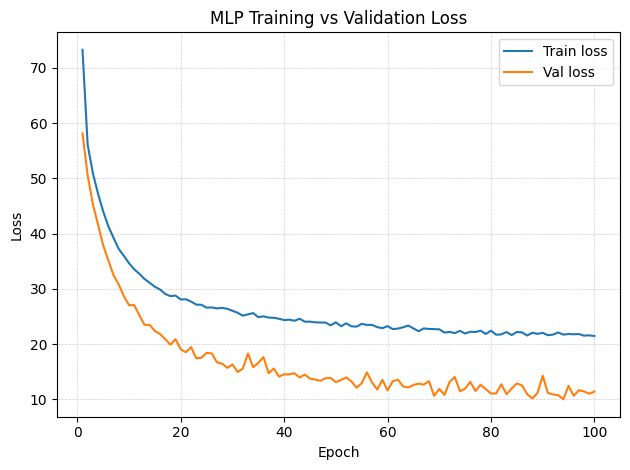

In [ ]:
mlp_model = MLPRegressorModel(hidden_layers=[50, 10], dropout=0.15, 
                                batch_size=128, num_epochs=100, learning_rate=0.001,
                                use_log_transform=True)
trainer.train_model(mlp_model)
mlp_preds = mlp_model.predict(X_test)

mlp_metrics = evaluator.evaluate(y_test_unscaled, mlp_preds, 'MLP')
evaluator.plot_predictions(y_test_unscaled, mlp_preds, 'MLP')
comparison.add_result('MLP', mlp_metrics)
trained_models['MLP'] = mlp_model

print(f"MLP - RMSE: {mlp_metrics['rmse']:.3f}, MSE: {mlp_metrics['mse']:.3f}, MAE: {mlp_metrics['mae']:.3f}, R²: {mlp_metrics['r2']:.3f}")

# Plot training loss if available
if hasattr(mlp_model, 'train_losses') and mlp_model.train_losses:
    plt.figure()
    epochs = range(1, len(mlp_model.train_losses) + 1)
    plt.plot(epochs, mlp_model.train_losses, label="Train loss")
    if mlp_model.val_losses:
        plt.plot(epochs, mlp_model.val_losses, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("MLP Training vs Validation Loss")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.tight_layout()
    plt.savefig('fig/mlp_training_loss.pdf')
    plt.show()


### Model Comparison

In [ ]:
# Generate comparison table
comparison_df = comparison.get_comparison_table()
comparison_df = comparison_df.round(3)
print(comparison_df)
comparison_df.to_csv('model_comparison_results_2.csv', index=False)
print("\n=== Model Comparison ===")
print(comparison_df.to_string(index=False))

# Save results
comparison.export_results('model_comparison_results.csv')

# Create comparison visualizations
comparison.plot_comparison()
comparison.plot_metric_comparison('rmse')
comparison.plot_metric_comparison('r2')

              model   rmse    mse    mae     r2
0  LightGBM (Tuned)  2.396  5.742  0.526  0.904
1               MLP  2.987  8.922  0.752  0.851

=== Model Comparison ===
           model  rmse   mse   mae    r2
LightGBM (Tuned) 2.396 5.742 0.526 0.904
             MLP 2.987 8.922 0.752 0.851


In [ ]:
latex = comparison_df.to_latex(
    index=False,
    escape=True,
    label="tab:your_label",
    column_format="l"*len(df.columns),
    float_format="%.3f"
)
print(latex)

\begin{table}
\label{tab:your_label}
\begin{tabular}{llllllllllllllllllll}
\toprule
model & rmse & mse & mae & r2 \\
\midrule
Random Forest & 0.937 & 0.879 & 0.396 & 0.984 \\
Gradient Boosting & 0.988 & 0.976 & 0.451 & 0.982 \\
Classical & 1.301 & 1.692 & 0.685 & 0.969 \\
Classical & 1.301 & 1.692 & 0.685 & 0.969 \\
XGBoost & 2.036 & 4.145 & 0.544 & 0.925 \\
LightGBM & 2.236 & 5.001 & 0.514 & 0.909 \\
KNN & 2.249 & 5.058 & 0.706 & 0.908 \\
SVR & 3.124 & 9.760 & 0.558 & 0.823 \\
MLP & 3.574 & 12.776 & 0.654 & 0.768 \\
Linear Regression & 4.273 & 18.259 & 2.075 & 0.668 \\
Elastic Net & 4.280 & 18.318 & 2.057 & 0.667 \\
\bottomrule
\end{tabular}
\end{table}



: 

### Hyperparameter Tuning

The following models will be tuned using Optuna:
- Elastic Net
- K-Nearest Neighbors (KNN)
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM
- SVR

Note: Linear Regression and Classical model don't have meaningful hyperparameters to tune.
MLP uses PyTorch and requires separate tuning approach.

#### Tuned Models Comparison


In [ ]:
# Final comparison including tuned models
tuned_comparison_df = comparison.get_comparison_table()
tuned_comparison_df = tuned_comparison_df.round(3)

print("=== All Models Comparison (including tuned) ===")
print(tuned_comparison_df.to_string(index=False))

# Save tuned model results
tuned_comparison_df.to_csv('model_comparison_with_tuning.csv', index=False)

# Create comparison visualizations
comparison.plot_comparison()
comparison.plot_metric_comparison('rmse')
comparison.plot_metric_comparison('r2')


=== All Models Comparison (including tuned) ===
                    model  rmse    mse   mae    r2
            Random Forest 0.938  0.880 0.395 0.984
    Random Forest (Tuned) 0.948  0.899 0.396 0.984
   Gradient Boosting (WE) 0.976  0.953 0.429 0.983
Gradient Boosting (Tuned) 0.987  0.975 0.451 0.982
        Gradient Boosting 0.988  0.976 0.451 0.982
       Random Forest (WE) 1.017  1.033 0.399 0.981
   Linear Regression (WE) 1.155  1.334 0.471 0.976
         Elastic Net (WE) 1.155  1.335 0.471 0.976
                Classical 1.301  1.692 0.685 0.969
                 KNN (WE) 1.358  1.844 0.559 0.966
                      MLP 1.919  3.681 0.838 0.933
              KNN (Tuned) 2.109  4.447 0.645 0.919
                      KNN 2.168  4.699 0.665 0.915
            LightGBM (WE) 2.201  4.845 0.485 0.912
             XGBoost (WE) 2.265  5.131 0.478 0.907
                  XGBoost 2.298  5.280 0.501 0.904
          XGBoost (Tuned) 2.298  5.280 0.501 0.904
         LightGBM (Tuned) 2.303  5

In [ ]:
# Print summary of all tuned models and their best parameters
print("=== Summary of Best Hyperparameters ===\n")
for model_name, model in tuned_models.items():
    print(f"{model_name}: {model.model_kwargs}")

=== Summary of Best Hyperparameters ===

Elastic Net: {'alpha': 0.0037460266483547782, 'l1_ratio': 0.8605714451279329}
KNN: {'n_neighbors': 7, 'weights': 'uniform', 'p': 2}
Random Forest: {'n_estimators': 55, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 3}
Gradient Boosting: {'n_estimators': 164, 'learning_rate': 0.0670976562737905, 'max_depth': 4, 'min_samples_split': 4}
XGBoost: {'n_estimators': 106, 'learning_rate': 0.19063571821788408, 'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.8312037280884873}
LightGBM: {'n_estimators': 106, 'learning_rate': 0.19063571821788408, 'max_depth': 6, 'num_leaves': 72, 'min_child_samples': 24}
SVR: {'C': 37.516557872851514, 'epsilon': 0.4758500101408589, 'kernel': 'rbf', 'gamma': 0.001}


In [ ]:
# Export final comparison to LaTeX for publication
latex = tuned_comparison_df.to_latex(
    index=False,
    escape=True,
    label="tab:model_comparison_tuned",
    column_format="l" + "r" * (len(tuned_comparison_df.columns) - 1),
    float_format="%.3f"
)
print("=== LaTeX Table ===")
print(latex)

=== LaTeX Table ===
\begin{table}
\label{tab:model_comparison_tuned}
\begin{tabular}{lrrrr}
\toprule
model & rmse & mse & mae & r2 \\
\midrule
Random Forest & 0.938 & 0.880 & 0.395 & 0.984 \\
Random Forest (Tuned) & 0.948 & 0.899 & 0.396 & 0.984 \\
Gradient Boosting (WE) & 0.976 & 0.953 & 0.429 & 0.983 \\
Gradient Boosting (Tuned) & 0.987 & 0.975 & 0.451 & 0.982 \\
Gradient Boosting & 0.988 & 0.976 & 0.451 & 0.982 \\
Random Forest (WE) & 1.017 & 1.033 & 0.399 & 0.981 \\
Linear Regression (WE) & 1.155 & 1.334 & 0.471 & 0.976 \\
Elastic Net (WE) & 1.155 & 1.335 & 0.471 & 0.976 \\
Classical & 1.301 & 1.692 & 0.685 & 0.969 \\
KNN (WE) & 1.358 & 1.844 & 0.559 & 0.966 \\
MLP & 1.919 & 3.681 & 0.838 & 0.933 \\
KNN (Tuned) & 2.109 & 4.447 & 0.645 & 0.919 \\
KNN & 2.168 & 4.699 & 0.665 & 0.915 \\
LightGBM (WE) & 2.201 & 4.845 & 0.485 & 0.912 \\
XGBoost (WE) & 2.265 & 5.131 & 0.478 & 0.907 \\
XGBoost & 2.298 & 5.280 & 0.501 & 0.904 \\
XGBoost (Tuned) & 2.298 & 5.280 & 0.501 & 0.904 \\
LightGBM (